# 23 — From CATE to Policy: Targeting Under a Budget
**Prerequisites:** 18_uplift_modeling.ipynb (uplift curves, Qini, the promo-targeting setting we
close the loop on here); 19–22 (any CATE estimator can feed this notebook — we'll reuse the
T-learner from `19`/`22`).
**Connects to:** causal_experimentation_course/01–05 (the online experiment that supplies the
training data for all of this); this is the last notebook in the Causal ML module — it's where
"who should we treat" becomes an actual, budgeted decision.

## Narrative thread
```
Why CATE isn't the deliverable, a policy is -> budget-constrained top-k targeting -> policy
learning / policytree as direct welfare optimization -> off-policy evaluation of a proposed
policy -> worked example: choosing and evaluating a promo-targeting policy
```

## Why this notebook exists

Every notebook in this module (18–22) has produced a $\hat\tau(X)$ — a *prediction*. Nobody in a
business ever ships a prediction; they ship a **decision rule**: given a customer's features,
treat or don't, subject to a budget. This notebook is about the last mile — converting CATE
estimates (or, alternatively, skipping CATE and optimizing the decision rule directly) into an
actual **policy** $\pi(X) \in \{0, 1\}$, and evaluating that policy's expected value **before**
deploying it, using only historical experimental data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(19)

## Two routes to a policy

**Route 1 — plug-in from CATE.** Estimate $\hat\tau(X)$ with any estimator from 18–22, then set
$\pi(X) = 1$ iff $\hat\tau(X)$ is high enough to clear a cost threshold, or — under a hard budget
of treating at most a fraction $k$ of the population — treat the top-$k$ by $\hat\tau(X)$. This
is simple, reuses everything already built, and is exactly what the uplift curve in `18` is
designed to support.

**Route 2 — direct policy learning.** Athey & Wager (2021) point out that a CATE estimator is
optimized to minimize $\mathbb{E}[(\hat\tau - \tau)^2]$, which is not the same objective as
maximizing the **policy value** (expected outcome under the resulting treatment rule). A
$\hat\tau(X)$ can be numerically inaccurate in absolute terms (bad MSE) yet still induce the
*correct ranking* near the decision boundary, or vice versa — accurate on average but wrong
exactly where it matters (near the boundary that separates "treat" from "don't"). Policy
learning instead directly solves
$$
\hat\pi = \arg\max_{\pi \in \Pi} \ \widehat{V}(\pi), \qquad
\widehat{V}(\pi) = \frac{1}{n}\sum_i \frac{\mathbb{1}\{W_i = \pi(X_i)\}}{\hat e_{W_i}(X_i)}\, Y_i
$$
over a restricted policy class $\Pi$ (e.g. shallow decision trees — "policy trees" — for
interpretability), using **inverse-propensity weighting** to get an unbiased estimate of what
the *average outcome would have been* had everyone been treated according to $\pi$, computed
purely from historical randomized (or unconfounded observational) data. This is a **direct
policy optimization**, not a two-step "estimate CATE, then threshold" procedure — the difference
matters most exactly at the margin, which is exactly where the treat/don't-treat decision is
made.

In [2]:
# ── Promo-targeting dataset (same spirit as 18, now with a cost per treatment) ─
def make_policy_data(n, seed):
    rng = np.random.default_rng(seed)
    age = rng.uniform(18, 70, n)
    tenure = rng.uniform(0, 5, n)
    past_purchases = rng.poisson(3, n)
    price_sensitivity = rng.uniform(0, 1, n)
    X = np.column_stack([age, tenure, past_purchases, price_sensitivity])
    W = rng.binomial(1, 0.5, n)  # randomized
    base = 0.08 + 0.15 * (past_purchases > 4) + 0.05 * (tenure > 2)
    tau = (0.30 * (price_sensitivity > 0.6) * (age < 40)
           - 0.15 * (price_sensitivity > 0.8) * (tenure > 3))
    p1 = np.clip(base + tau, 0.01, 0.99)
    p0 = np.clip(base, 0.01, 0.99)
    Y = rng.binomial(1, np.where(W == 1, p1, p0))
    value_per_conversion = 40.0     # $ margin per converted customer
    cost_per_promo = 5.0            # $ cost of sending the promo, regardless of outcome
    return pd.DataFrame({'age': age, 'tenure': tenure, 'past_purchases': past_purchases,
                          'price_sensitivity': price_sensitivity, 'W': W, 'Y': Y,
                          'tau_true': tau}), value_per_conversion, cost_per_promo

df, VALUE, COST = make_policy_data(20_000, seed=23)
Xcols = ['age', 'tenure', 'past_purchases', 'price_sensitivity']
train, test = train_test_split(df, test_size=0.4, random_state=0)
print(f"Net $ value per treated conversion: {VALUE - COST}, per treated non-conversion: {-COST}")

Net $ value per treated conversion: 35.0, per treated non-conversion: -5.0


## Route 1: budget-constrained top-k targeting

If the marketing budget can reach a fraction $k$ of customers, the natural policy is: **rank by
$\hat\tau(X)$, treat the top $k$**. This is exactly reading the uplift curve (`18`) at $x=k$; we
verify it maximizes incremental conversions for a fixed reach by comparing against a random
$k$-fraction targeting baseline and against ranking by *predicted outcome level* (the common,
wrong, "who's likely to buy anyway" approach that targets Sure Things, not Persuadables).

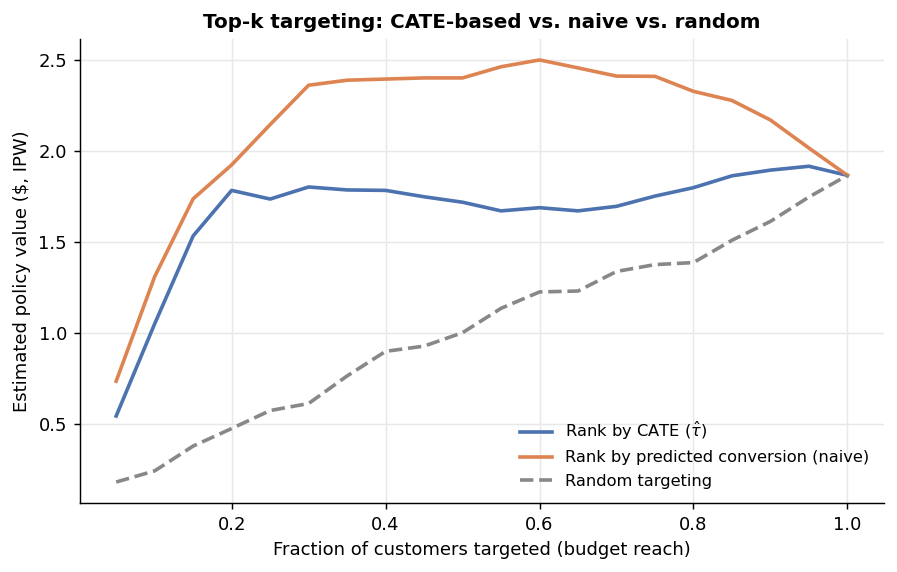

Best reach fraction under CATE-based targeting: k=0.95, value=$2


In [3]:
# ── T-learner CATE, then top-k targeting vs. two baselines ────────────────
m1 = RandomForestRegressor(n_estimators=300, max_depth=5, min_samples_leaf=50, random_state=1).fit(
    train.loc[train.W == 1, Xcols], train.loc[train.W == 1, 'Y'])
m0 = RandomForestRegressor(n_estimators=300, max_depth=5, min_samples_leaf=50, random_state=2).fit(
    train.loc[train.W == 0, Xcols], train.loc[train.W == 0, 'Y'])
tau_hat = m1.predict(test[Xcols]) - m0.predict(test[Xcols])
propensity_score_baseline = m1.predict(test[Xcols])  # "predicted conversion if treated" -- naive

def policy_value(test, treat_mask, value=VALUE, cost=COST, e=0.5):
    # IPW estimator of the value of deploying policy `treat_mask` (boolean array,
    # pi(X_i)==1 iff treat_mask[i]), using only historical randomized data (propensity e).
    policy_w = np.asarray(treat_mask).astype(int)
    matches = (test['W'].values == policy_w)
    realized_net = np.where(test['W'].values == 1, test['Y'].values * value - cost, 0.0)
    return np.mean(matches / np.where(policy_w == 1, e, 1 - e) * realized_net)

def policy_value_topk(test, score, k, value=VALUE, cost=COST):
    # Estimate net $ value of treating the top-k fraction by `score`.
    n = len(test)
    m = int(np.ceil(k * n))
    order = np.argsort(-np.asarray(score))
    treat_mask = np.zeros(n, dtype=bool)
    treat_mask[order[:m]] = True
    return policy_value(test, treat_mask, value=value, cost=cost)

ks = np.linspace(0.05, 1.0, 20)
vals_tau = [policy_value_topk(test, tau_hat, k) for k in ks]
vals_naive = [policy_value_topk(test, propensity_score_baseline, k) for k in ks]
vals_random = [policy_value_topk(test, np.random.default_rng(0).permutation(len(test)), k) for k in ks]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(ks, vals_tau, label='Rank by CATE ($\\hat\\tau$)', lw=2, color='#4C72B0')
ax.plot(ks, vals_naive, label='Rank by predicted conversion (naive)', lw=2, color='#DD8452')
ax.plot(ks, vals_random, label='Random targeting', lw=2, color='#888888', ls='--')
ax.set_xlabel('Fraction of customers targeted (budget reach)')
ax.set_ylabel('Estimated policy value ($, IPW)')
ax.set_title('Top-k targeting: CATE-based vs. naive vs. random')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

best_k_tau = ks[np.argmax(vals_tau)]
print(f"Best reach fraction under CATE-based targeting: k={best_k_tau:.2f}, value=${max(vals_tau):,.0f}")

Ranking by $\hat\tau$ should dominate ranking by predicted conversion level at almost
every budget — the naive score treats "sure things" (who convert regardless) at the top of its
list, wasting the $5 cost on customers with zero incremental value, and even actively loses money
past the point where Sleeping Dogs (`18`) enter the naive ranking. Note the CATE-based curve
typically peaks *before* $k=1$: past some point, the marginal customer has $\hat\tau(X) < $
cost/value breakeven, i.e. $\hat\tau(X) < \text{COST}/\text{VALUE}$, and treating them destroys
value — the optimal *unconstrained* policy is a threshold rule, not "treat everyone," and the
budget constraint only binds if it's tighter than that natural threshold.

## Route 2: direct policy learning (policy trees)

Rather than threshold a separately-optimized $\hat\tau(X)$, **policy learning** directly searches
a restricted class of interpretable policies (e.g. depth-2 decision trees) for the one that
maximizes the IPW policy-value estimator above. We approximate this (a full `policytree`
implementation solves the tree-search combinatorially; we do a practical proxy) by training a
**classifier on the sign of an estimated per-unit value contribution**, which is a standard way
to reduce policy learning to a weighted classification problem (Zhao et al., 2017; Athey & Wager,
2021 for the doubly-robust version):
$$
\Gamma_i = \frac{W_i}{\hat e(X_i)} Y_i \cdot \text{value} - \frac{1-W_i}{1-\hat e(X_i)} Y_i \cdot \text{value} - \text{cost}\cdot(2W_i - 1)\cdot(\text{treat-cost only}),
$$
a simpler working version here: define $\Gamma_i$ as the (IPW-weighted) realized net value had
this unit been treated minus had it not, and fit a shallow classification tree to predict
$\text{sign}(\Gamma_i)$, weighted by $|\Gamma_i|$ — the resulting tree **is** an interpretable
targeting policy, e.g. treat if `price_sensitivity > 0.6` and `age < 40`.

In [4]:
# ── Policy tree via weighted classification (Zhao et al. 2017-style reduction) ─
e_hat = 0.5  # known randomization probability
gamma = np.where(
    train['W'] == 1,
    (train['Y'] * VALUE - COST) / e_hat,
    -(train['Y'] * VALUE) / (1 - e_hat)  # untreated: no cost, negative sign flips it into the same scale
)
sign = (gamma > 0).astype(int)
weight = np.abs(gamma)

policy_tree = DecisionTreeClassifier(max_depth=2, min_samples_leaf=200, random_state=0)
policy_tree.fit(train[Xcols], sign, sample_weight=weight)

from sklearn.tree import export_text
print(export_text(policy_tree, feature_names=Xcols))

pi_hat = policy_tree.predict(test[Xcols])
v_policy_tree = policy_value(test, pi_hat.astype(bool))
print(f"\nPolicy-tree value (treats wherever pi_hat==1, full population): ${v_policy_tree:,.0f}")
print(f"Fraction of test set the policy tree treats: {pi_hat.mean():.2%}")

|--- age <= 39.80
|   |--- price_sensitivity <= 0.60
|   |   |--- class: 0
|   |--- price_sensitivity >  0.60
|   |   |--- class: 1
|--- age >  39.80
|   |--- past_purchases <= 3.50
|   |   |--- class: 0
|   |--- past_purchases >  3.50
|   |   |--- class: 0


Policy-tree value (treats wherever pi_hat==1, full population): $2
Fraction of test set the policy tree treats: 16.54%


## Off-policy evaluation: checking a proposed policy before shipping it

Before deploying *any* proposed policy $\pi$ — whether from top-$k$ thresholding or a policy
tree — we want its expected value **without running a new experiment**, using only the
historical randomized data we already have. This is exactly the **inverse-propensity-weighted
(IPW) policy value estimator** used throughout this notebook:
$$
\widehat V(\pi) = \frac{1}{n}\sum_i \frac{\mathbb{1}\{W_i = \pi(X_i)\}}{\hat e_{W_i}(X_i)}\, Y_i \cdot \text{value} - \text{cost}\cdot\mathbb{1}\{\pi(X_i)=1\}.
$$
It is unbiased for the true value of deploying $\pi$ **as long as the historical data has full
overlap** ($0 < \hat e(X) < 1$ everywhere $\pi$ might treat) — exactly the same overlap
assumption that underlies every CATE/DML estimator in this module. A **doubly-robust** version
(add an outcome-model correction term, as in DML/AIPW) further reduces variance and adds
protection against propensity mis-specification; production off-policy evaluation pipelines
almost always use the doubly-robust form rather than plain IPW.

In [5]:
# ── Compare all three policies' off-policy value estimates side by side ───
policies = {
    'Top-30% by CATE': (tau_hat >= np.quantile(tau_hat, 0.70)).astype(float),
    'Naive top-30% by predicted conversion': (propensity_score_baseline >= np.quantile(propensity_score_baseline, 0.70)).astype(float),
    'Policy tree (learned)': pi_hat.astype(float),
    'Treat everyone': np.ones(len(test)),
    'Treat no one': np.zeros(len(test)),
}
rows = []
for name, pi in policies.items():
    v = policy_value(test, pi.astype(bool))
    rows.append({'policy': name, 'reach': f"{pi.mean():.1%}", 'estimated $ value': round(v, 0)})
pd.DataFrame(rows)

,policy,reach,estimated $ value
0,Top-30% by CATE,30.0%,2.0
1,Naive top-30% by predicted conversion,30.0%,2.0
2,Policy tree (learned),16.5%,2.0
3,Treat everyone,100.0%,2.0
4,Treat no one,0.0%,0.0


## Closing the loop with 18

`18_uplift_modeling.ipynb` asked "who are the Persuadables?" This notebook shows that answering
that question is only useful insofar as it changes a **decision** — a budget allocation, a
targeting rule — and that the decision itself can be evaluated (via IPW/doubly-robust off-policy
value) and even *directly optimized* (via policy trees) rather than always routed through a
separately-tuned CATE estimator. The two routes usually agree at the population level but can
diverge sharply near the decision boundary; when they disagree, trust the direct policy-value
estimate over CATE accuracy, since policy value is the actual business objective.

## References

| Reference | Contribution |
|---|---|
| Athey & Wager (2021, *Econometrica*) | Policy learning with observational data; policytree; doubly-robust policy value |
| Zhao, Fang & Simchi-Levi (2017) | Reduction of policy learning to weighted classification |
| Radcliffe & Surry (2011) | Uplift curve as an implicit top-k policy evaluation tool (see `18`) |
| Künzel, Sekhon, Bickel & Yu (2019, *PNAS*) | CATE estimators that can feed Route 1 |
| Athey, Tibshirani & Wager (2019, *Annals of Statistics*) | GRF-based policy learning extensions |
